        Date   City   PM2.5    PM10    NO2    SO2    CO     O3    AQI  \
0 2023-01-01  Delhi  152.16  180.04  21.21  39.10  0.22  32.77  382.9   
1 2023-01-02  Delhi  136.64  186.65  78.76   8.23  2.17  10.81  393.7   
2 2023-01-03  Delhi  159.41  169.58  76.17  31.88  3.06  25.58  412.9   
3 2023-01-04  Delhi  135.75  181.47  35.63  22.06  3.29  56.95  366.6   
4 2023-01-05  Delhi  147.07  173.11  52.82  17.26  2.34  45.72  385.5   

   Temperature  Humidity  
0         33.7      74.6  
1         33.2      23.1  
2         30.1      62.1  
3         30.4      31.1  
4         35.6      73.7  

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         300 non-null    datetime64[us]
 1   City         300 non-null    str           
 2   PM2.5        300 non-null    float64       
 3   PM10         300 non-null    float64       
 4   NO2  

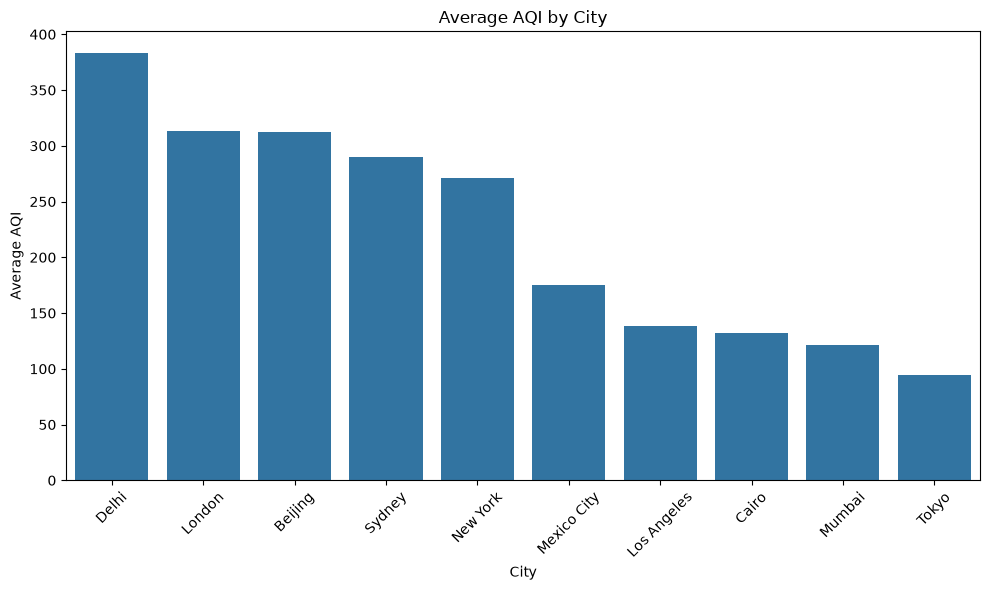

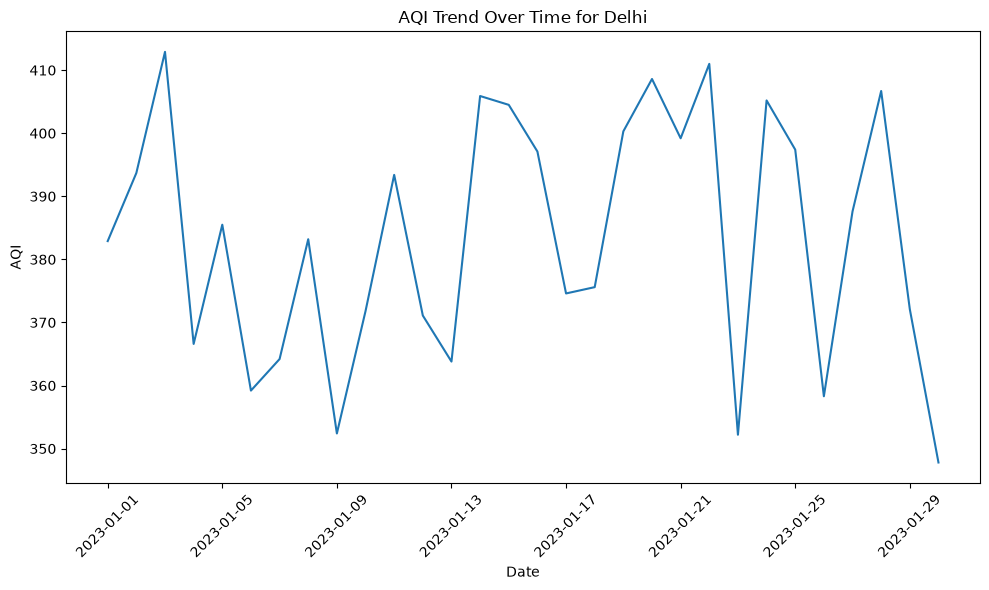

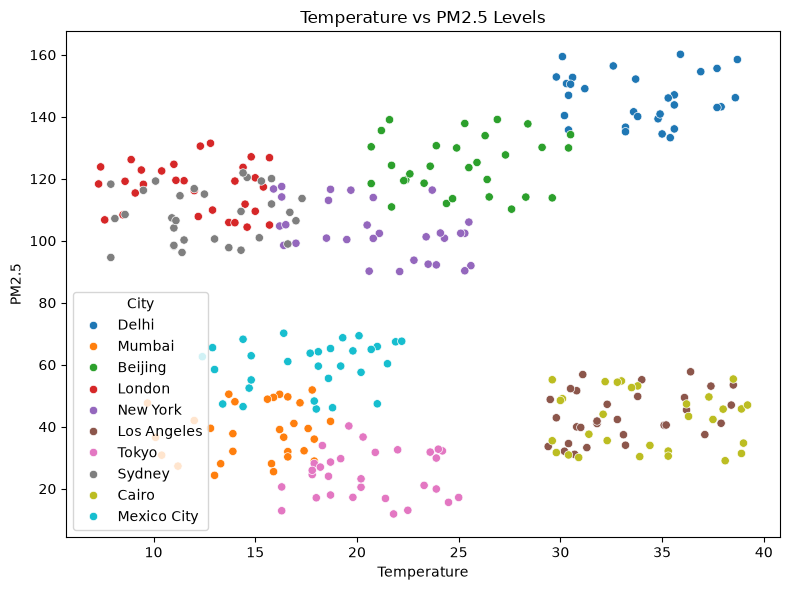

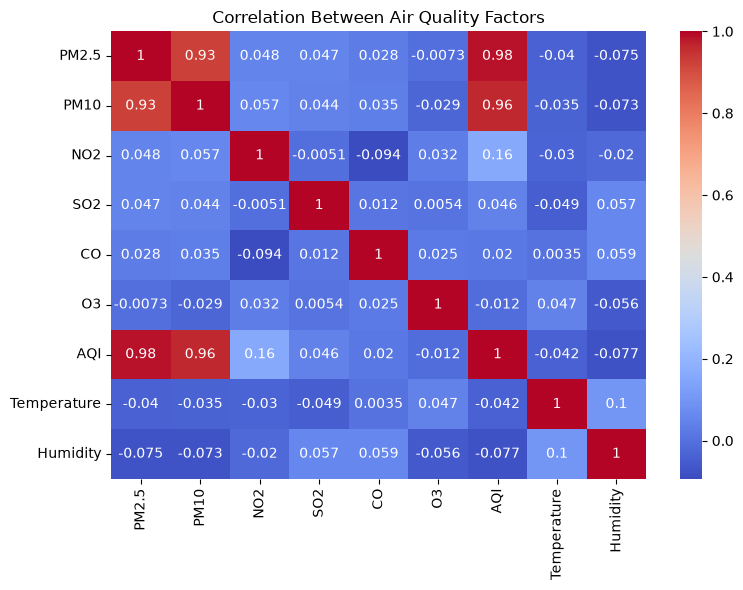

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("air_quality_data.csv")
df["Date"] = pd.to_datetime(df["Date"])

print(df.head())
print()
print(df.info())
print()
print(df.describe())
print()
print(df.isnull().sum())

city_avg_aqi = df.groupby("City")["AQI"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=city_avg_aqi.index, y=city_avg_aqi.values)
plt.xticks(rotation=45)
plt.title("Average AQI by City")
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.tight_layout()
plt.show()

worst_city = city_avg_aqi.index[0]
worst_city_data = df[df["City"] == worst_city]

plt.figure(figsize=(10, 6))
sns.lineplot(x="Date", y="AQI", data=worst_city_data)
plt.title("AQI Trend Over Time for " + worst_city)
plt.xlabel("Date")
plt.ylabel("AQI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x="Temperature", y="PM2.5", data=df, hue="City")
plt.title("Temperature vs PM2.5 Levels")
plt.xlabel("Temperature")
plt.ylabel("PM2.5")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
correlation = df[["PM2.5", "PM10", "NO2", "SO2", "CO", "O3", "AQI", "Temperature", "Humidity"]].corr()
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Between Air Quality Factors")
plt.tight_layout()
plt.show()